## Modeling avec MLflow

### Imports

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, 
                             roc_auc_score, precision_score, 
                             recall_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("✅ Libraries importées avec succès")

✅ Libraries importées avec succès


### Charger les données prétraitées

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (13038, 8)
X_test  : (2000, 8)
y_train : (13038,)
y_test  : (2000,)


### Configurer MLflow

In [3]:
# Configurer le dossier mlruns
mlflow.set_tracking_uri("file:../mlruns")

print("✅ MLflow configuré")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")

✅ MLflow configuré
Tracking URI : file:../mlruns


### Fonction d'évaluation

In [4]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "accuracy"  : accuracy_score(y_test, y_pred),
        "f1_score"  : f1_score(y_test, y_pred),
        "roc_auc"   : roc_auc_score(y_test, y_proba),
        "precision" : precision_score(y_test, y_pred),
        "recall"    : recall_score(y_test, y_pred)
    }
    return metrics, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non Défaut', 'Défaut'],
                yticklabels=['Non Défaut', 'Défaut'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    path = f'../data/{model_name}_confusion_matrix.png'
    plt.savefig(path)
    plt.show()
    return path

print("✅ Fonctions définies")

✅ Fonctions définies


### Modèle 1 : Régression Logistique

/Users/batoulzorkot/Desktop/loan-default-mlops/venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/09 10:52:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:52:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


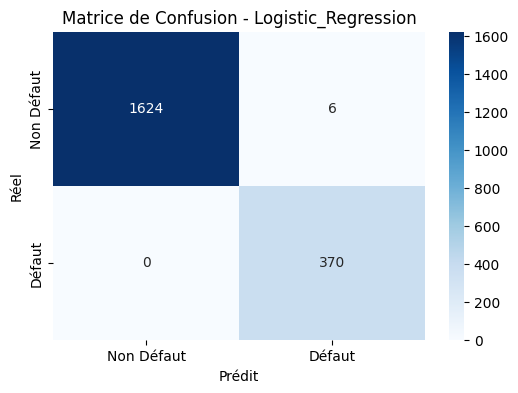

📊 RÉGRESSION LOGISTIQUE
accuracy     : 0.9970
f1_score     : 0.9920
roc_auc      : 1.0000
precision    : 0.9840
recall       : 1.0000

MLflow Run ID : 6f132fe49baf47e4854ec9e338eaeb99


In [5]:
mlflow.set_experiment("Logistic_Regression")

with mlflow.start_run(run_name="logistic_regression_v1"):
    
    # Entraînement
    model_lr = LogisticRegression(max_iter=1000, random_state=42)
    model_lr.fit(X_train, y_train)
    
    # Evaluation
    metrics, y_pred = evaluate_model(model_lr, X_test, y_test)
    
    # Logger les paramètres
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("solver", "lbfgs")
    
    # Logger les métriques
    mlflow.log_metrics(metrics)
    
    # Logger le modèle
    mlflow.sklearn.log_model(model_lr, "logistic_regression_model")
    
    # Logger la matrice de confusion
    cm_path = plot_confusion_matrix(y_test, y_pred, "Logistic_Regression")
    mlflow.log_artifact(cm_path)
    
    print("=" * 50)
    print("📊 RÉGRESSION LOGISTIQUE")
    print("=" * 50)
    for k, v in metrics.items():
        print(f"{k:12} : {v:.4f}")
    print("=" * 50)
    
    run_id_lr = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID : {run_id_lr}")

### Modèle 2 : Decision Tree

2026/04/09 10:52:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:52:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


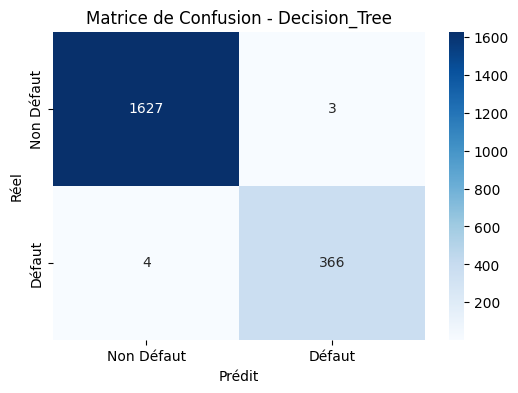

📊 DECISION TREE
accuracy     : 0.9965
f1_score     : 0.9905
roc_auc      : 0.9937
precision    : 0.9919
recall       : 0.9892

MLflow Run ID : dce5fdcfdd9e4b358b00592e11b40c7b


In [6]:
mlflow.set_experiment("Decision_Tree")

with mlflow.start_run(run_name="decision_tree_v1"):
    
    # Entraînement
    model_dt = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=5,
        random_state=42
    )
    model_dt.fit(X_train, y_train)
    
    # Evaluation
    metrics, y_pred = evaluate_model(model_dt, X_test, y_test)
    
    # Logger les paramètres
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("random_state", 42)
    
    # Logger les métriques
    mlflow.log_metrics(metrics)
    
    # Logger le modèle
    mlflow.sklearn.log_model(model_dt, "decision_tree_model")
    
    # Logger la matrice de confusion
    cm_path = plot_confusion_matrix(y_test, y_pred, "Decision_Tree")
    mlflow.log_artifact(cm_path)
    
    print("=" * 50)
    print("📊 DECISION TREE")
    print("=" * 50)
    for k, v in metrics.items():
        print(f"{k:12} : {v:.4f}")
    print("=" * 50)
    
    run_id_dt = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID : {run_id_dt}")

### Modèle 3 : Random Forest

2026/04/09 10:52:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:52:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


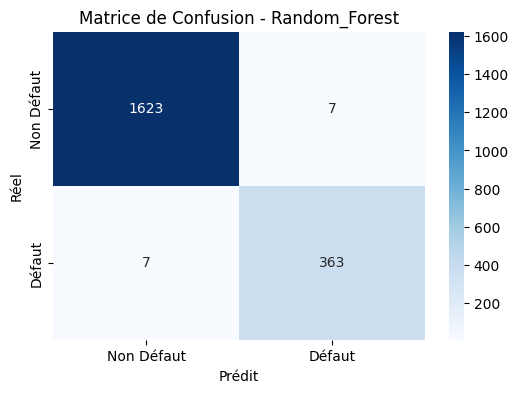

📊 RANDOM FOREST
accuracy     : 0.9930
f1_score     : 0.9811
roc_auc      : 0.9998
precision    : 0.9811
recall       : 0.9811

MLflow Run ID : 36d4cfbd85b24bfeb85194172cd309aa


In [7]:
mlflow.set_experiment("Random_Forest")

with mlflow.start_run(run_name="random_forest_v1"):
    
    # Entraînement
    model_rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    model_rf.fit(X_train, y_train)
    
    # Evaluation
    metrics, y_pred = evaluate_model(model_rf, X_test, y_test)
    
    # Logger les paramètres
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("random_state", 42)
    
    # Logger les métriques
    mlflow.log_metrics(metrics)
    
    # Logger le modèle
    mlflow.sklearn.log_model(model_rf, "random_forest_model")
    
    # Logger la matrice de confusion
    cm_path = plot_confusion_matrix(y_test, y_pred, "Random_Forest")
    mlflow.log_artifact(cm_path)
    
    print("=" * 50)
    print("📊 RANDOM FOREST")
    print("=" * 50)
    for k, v in metrics.items():
        print(f"{k:12} : {v:.4f}")
    print("=" * 50)
    
    run_id_rf = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID : {run_id_rf}")

### Comparaison des modèles

📊 COMPARAISON DES MODÈLES
                     accuracy  f1_score  roc_auc  precision  recall
Logistic Regression    0.9970    0.9920   1.0000     0.9840  1.0000
Decision Tree          0.9965    0.9905   0.9937     0.9919  0.9892
Random Forest          0.9930    0.9811   0.9998     0.9811  0.9811

🏆 Meilleur modèle (AUC-ROC) : Logistic Regression


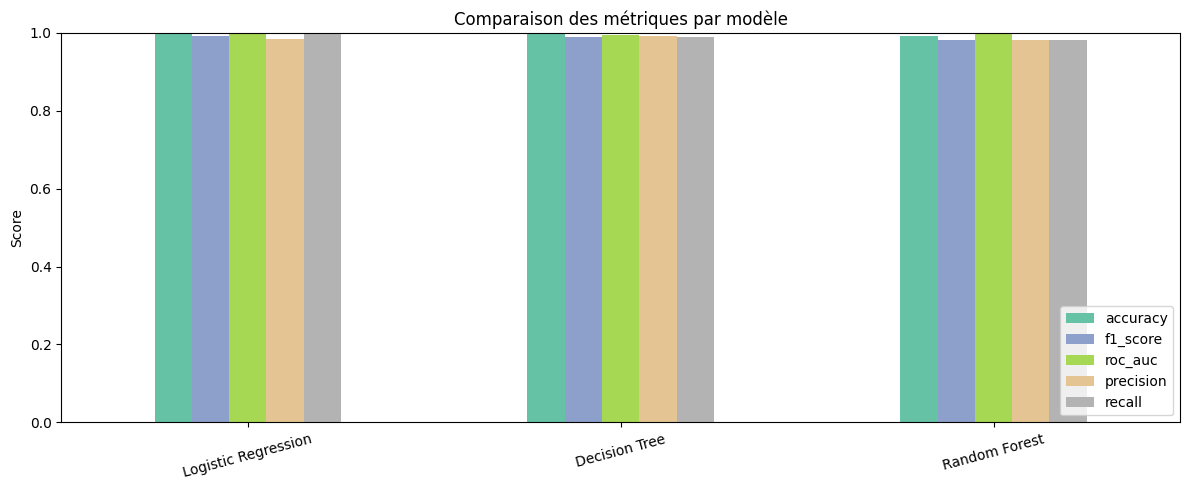

In [8]:
results = {
    "Logistic Regression": evaluate_model(model_lr, X_test, y_test)[0],
    "Decision Tree"      : evaluate_model(model_dt, X_test, y_test)[0],
    "Random Forest"      : evaluate_model(model_rf, X_test, y_test)[0],
}

df_results = pd.DataFrame(results).T
print("=" * 60)
print("📊 COMPARAISON DES MODÈLES")
print("=" * 60)
print(df_results.round(4))
print("=" * 60)
print(f"\n🏆 Meilleur modèle (AUC-ROC) : {df_results['roc_auc'].idxmax()}")

# Visualisation
df_results.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Comparaison des métriques par modèle')
plt.xticks(rotation=15)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/models_comparison.png')
plt.show()

### Sauvegarder le meilleur modèle

In [9]:
# Sauvegarder le meilleur modèle (Random Forest en général)
best_model = model_rf
os.makedirs('../data/processed', exist_ok=True)
joblib.dump(best_model, '../data/processed/best_model.pkl')

print("✅ Meilleur modèle sauvegardé : data/processed/best_model.pkl")
print(f"Modèle : {type(best_model).__name__}")

✅ Meilleur modèle sauvegardé : data/processed/best_model.pkl
Modèle : RandomForestClassifier


###  Lancer l'UI MLflow

In [10]:
print("Pour visualiser les expériences MLflow, lance dans le terminal :")
print("mlflow ui --backend-store-uri file:../mlruns")
print("Puis ouvre : http://127.0.0.1:5000")

Pour visualiser les expériences MLflow, lance dans le terminal :
mlflow ui --backend-store-uri file:../mlruns
Puis ouvre : http://127.0.0.1:5000
